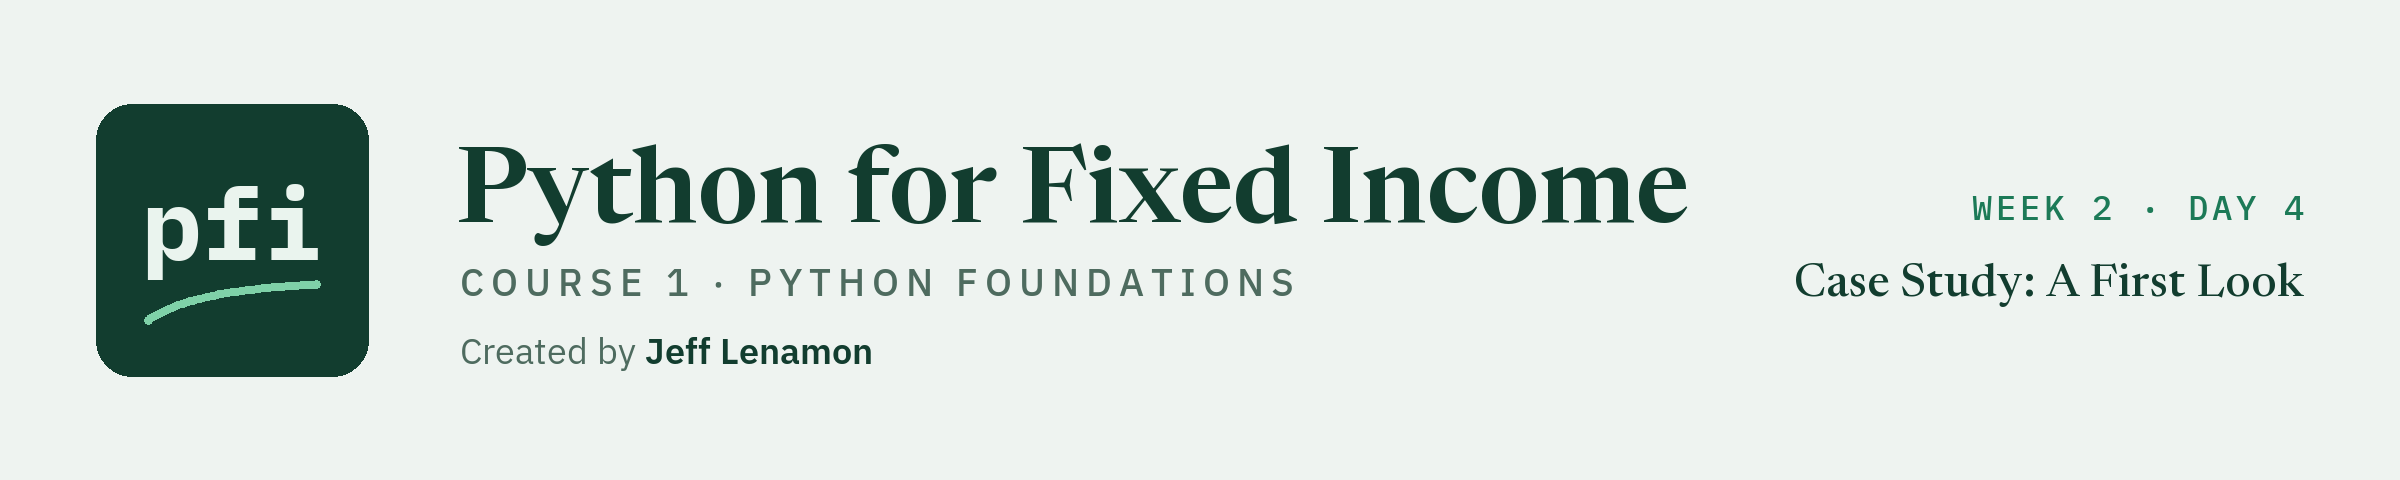

# Case Study: A First Look at the Data

Week 2. Three tables arrive from three systems, and each one gets a careful look before anything is joined.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course1_python_foundations/week2/day4/09_case_study_first_look_at_the_data.ipynb)

## Problem Definition

### Context

A credit desk has moved to a new set of systems. The positions now come from the trading system. The issuer details come from a reference data system. The rating scale comes from a third. Each system sends its own file, and the three files were built by different teams at different times.

The desk's reports need all three: a position means little without its issuer's sector and rating, and a rating cannot be sorted or grouped without the scale. Nobody has yet checked that the three files fit together.

### Objective

You are the desk's analyst. Before any report is built, your job is to:

* get to know each table on its own: what one row is, how large the table is, what type each column has, and what the values look like,
* check each table for missing values and repeated rows,
* check that the columns used to connect the tables will connect them cleanly, and
* report what you found and whether the tables are ready to be joined.

Nothing is joined today. The join is tomorrow's work, and it goes well only if today's is done first.

### The data

Three files, all in the `data` folder of the course repo. The issuers and the CUSIPs are invented. The as-of date is 2026-09-30. Every bond is a fixed-rate bullet bond paying semiannual coupons.

**`positions.csv`**, from the trading system: what the desk holds.

| Column | Meaning | Units |
| --- | --- | --- |
| `cusip` | identifier of the bond | nine characters |
| `ticker` | short code of the issuer | four letters |
| `coupon` | annual coupon rate | percent |
| `maturity` | maturity date | year-month-day |
| `price` | clean price | per 100 of face |
| `par_held` | face amount the desk holds | dollars of face |

**`issuers.csv`**, from the reference data system: who the issuers are.

| Column | Meaning |
| --- | --- |
| `ticker` | short code of the issuer |
| `issuer` | issuer name |
| `sector` | industry sector |
| `country` | country of the issuer |
| `rating` | credit rating of the issuer, as letters |

These files carry one rating per issuer, and every bond of that issuer takes it. In real data a rating belongs to the bond, and a subordinated or secured bond can be rated a notch or more away from its issuer.

**`ratings.csv`**, the rating scale.

| Column | Meaning |
| --- | --- |
| `rating` | the rating, as letters |
| `score` | the rating as a number: 1 for AAA, one more for each notch lower |
| `bucket` | the rating with the plus or minus removed |
| `grade` | Investment Grade or High Yield |

### How we will work

Every table gets the same routine, in the same order:

1. **First rows.** Look at a few rows and say what one row stands for.
2. **Shape.** Count the rows and the columns.
3. **Data types.** Check what pandas thinks each column holds.
4. **Summary.** Look at the range of the numbers and the variety of the text.
5. **Missing values and duplicates.** Count the gaps and the repeated rows.
6. **The key.** Find the column that connects this table to the others, and test it.

Every tool in the routine is from the last two notebooks, apart from a few small ones that are explained where they first appear. What is new today is the habit: look before you join.

## 1.0 Loading the three tables

### 1.1 Importing pandas

Q. Import pandas, and check which version is running.

In [1]:
# os is used in the next cell to find the data folder
import os

import pandas as pd

print('pandas version:', pd.__version__)

pandas version: 3.0.6


* This notebook was saved with pandas 3.0.6. Your version may differ, and in Google Colab it may be older.
* One difference will show today. A column of text has the type `str` in pandas 3 and `object` in older versions. Wherever an output below says `str`, an older version says `object`. A few smaller details also differ between versions, such as the unit shown on a date column and the wording of some error messages, and they are noted where they appear.

### 1.2 Finding the data folder

In [2]:
# on your own machine the files are in the repo's data folder. In Colab they are read from GitHub.
if os.path.exists('../../../data/positions.csv'):
    data_folder = '../../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

* The same cell as yesterday. `data_folder` holds the location of the folder, and each file name is added to it.

### 1.3 Reading the files

Q. Read each file into its own DataFrame.

In [3]:
# one table per file, each named after what it holds
positions = pd.read_csv(data_folder + 'positions.csv')
issuers = pd.read_csv(data_folder + 'issuers.csv')
ratings = pd.read_csv(data_folder + 'ratings.csv')

* Nothing is printed, and no error appeared. That says the files were found and read. It says nothing yet about what is in them.

Q. How many rows did each file bring?

In [4]:
# len() of a DataFrame is its number of rows
print('positions:', len(positions))
print('issuers:', len(issuers))
print('ratings:', len(ratings))

positions: 200
issuers: 150
ratings: 18


* 200 positions, 150 issuers, and 18 ratings. Three tables of three different sizes, so each row must stand for something different in each. That is the first thing to find out.

**Excel side by side.** This is three workbooks open at once, one from each system. The routine that follows is what a careful analyst does with a new workbook before writing a single `VLOOKUP` against it.

## 2.0 The positions table

The positions file is the one the desk cares about most: it is the list of what the desk owns. It comes from the trading system.

### 2.1 First rows

Q. What do the first five rows look like?

In [5]:
# head() with nothing in the brackets shows the first 5 rows
positions.head()

,cusip,ticker,coupon,maturity,price,par_held
0,99080CAE8,BEZE,7.000,2032-06-18,106.727,5000000
1,99049XAE2,BEZH,8.125,2029-04-17,97.556,250000
2,99039NAC0,BEZL,5.125,2030-06-03,98.730,1500000
3,99039NAG1,BEZL,6.125,2053-04-09,92.261,500000
4,99034IAD4,BEZN,4.625,2036-04-05,92.883,2500000


* Six columns. The first bond is the BEZE 7% maturing 2032-06-18, priced at 106.727, with 5,000,000 of face held.
* The ticker BEZL appears twice, in rows 2 and 3, with two different CUSIPs, coupons, and maturities. So a ticker can repeat in this table.

Q. And the last three rows?

In [6]:
positions.tail(3)

,cusip,ticker,coupon,maturity,price,par_held
197,99062KAA0,ZEPL,4.125,2036-11-12,90.863,1250000
198,99138IAD9,ZEPN,7.250,2031-09-13,110.669,750000
199,99138IAF4,ZEPN,5.000,2036-08-16,93.656,2500000


* The last label is 199, so the rows are numbered 0 to 199. ZEPN appears twice here as well.
* The file starts at BEZE and ends at ZEPN: the rows arrive in ticker order.

Q. Show one row on its own. What does one row of this table stand for?

In [7]:
# iloc[0] is the first row, shown as a Series with the column names as labels
positions.iloc[0]

cusip        99080CAE8
ticker            BEZE
coupon             7.0
maturity    2032-06-18
price          106.727
par_held       5000000
Name: 0, dtype: object

* One row is **one bond the desk holds**: its identifier, its issuer's ticker, its terms, its price, and the size of the position.
* The CUSIP is what identifies the bond. The ticker identifies the issuer, and an issuer can have many bonds.
* The last line reads `dtype: object`, because a row mixes text and numbers.

### 2.2 Shape

Q. How many rows and columns does the table have?

In [8]:
# shape is (rows, columns)
positions.shape

(200, 6)

* (200, 6): 200 bonds and six columns.

**Predict 1**

The first five rows are stored under a new name, and the shape of that is printed:

```
first_rows = positions.head()
print(first_rows.shape)
print(positions.shape)
```

What do the two lines print?

> A) (200, 6) and (200, 6)
>
> B) (5, 6) and (5, 6)
>
> C) (5, 6) and (200, 6)

Decide, then run the cell.

In [9]:
first_rows = positions.head()
print(first_rows.shape)
print(positions.shape)

(5, 6)
(200, 6)


* The answer is C. `head()` returns a new, smaller table of five rows and the same six columns. It does not cut anything from `positions`, which still has all 200 rows.
* Looking at a table with `head()`, `tail()`, or a filter never changes it. A table changes only when something is assigned back to it.

Q. What are the column names?

In [10]:
# tolist() gives the names as a plain list
positions.columns.tolist()

['cusip', 'ticker', 'coupon', 'maturity', 'price', 'par_held']

* Six names, lower case, with an underscore in `par_held`. A column is always asked for by its exact name, so it pays to print the names once and copy them from here.

**Excel side by side.** For the shape of a sheet, press `Ctrl+End` to jump to the last used cell and read its row and column. Or select a column and read the count in the status bar at the bottom of the window. That count includes the header cell, so it reads 201 for this sheet: subtract one. In pandas it is `shape`, and it never counts a stray formatted cell far below the data.

### 2.3 Data types

pandas decides the type of each column when it reads the file. It is worth checking, because the type decides what can be done with the column.

**Predict 2**

The first maturity in the file is written `2032-06-18`. What type does pandas give the `maturity` column?

> A) A date, because the values are written as dates.
>
> B) Text, because a CSV file holds nothing but characters.
>
> C) A number, because the values are made of digits.

Decide, then run the cell.

In [11]:
# the type of the column, then the type of its first value
print(positions['maturity'].dtype)
print(type(positions['maturity'].iloc[0]))

str
<class 'str'>


* The answer is B. The column is `str`, or `object` in older versions of pandas, and the first value is a Python `str`: ten characters that happen to look like a date.
* `read_csv` turns columns of digits into numbers by itself. It does not turn text into dates unless it is told to, with `parse_dates=` or with `pd.to_datetime()`, both from yesterday.

Q. What is the type of every column?

In [12]:
# dtypes lists the type of each column
positions.dtypes

cusip           str
ticker          str
coupon      float64
maturity        str
price       float64
par_held      int64
dtype: object

* `coupon` and `price` are `float64`, numbers with decimals. `par_held` is `int64`, whole numbers. Those three are ready for arithmetic.
* `cusip`, `ticker`, and `maturity` are text: `str` here, `object` in older versions. For the CUSIP and the ticker that is right. For the maturity it is a finding: date arithmetic will not work on this column as it arrived.

Q. Show the types together with the number of values in each column.

In [13]:
# info() lists every column with its count of non-missing values and its type
positions.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   cusip     200 non-null    str    
 1   ticker    200 non-null    str    
 2   coupon    200 non-null    float64
 3   maturity  200 non-null    str    
 4   price     200 non-null    float64
 5   par_held  200 non-null    int64  
dtypes: float64(2), int64(1), str(3)
memory usage: 9.5 KB


* Six columns, each with 200 non-null values, in a table of 200 rows. 'Non-null' means not missing, so this is the first sign that nothing is missing. Section 2.5 checks it directly.

Q. Convert the maturities to real dates, without changing the table. What are the earliest and the latest maturity, and how far is the latest from the as-of date?

In [14]:
# the dates are stored in a separate Series, so positions stays as it arrived
maturity_dates = pd.to_datetime(positions['maturity'])
print(maturity_dates.dtype)

as_of = pd.Timestamp('2026-09-30')
print('Earliest maturity:', maturity_dates.min().date())
print('Latest maturity:', maturity_dates.max().date())

# a date minus a date is a length of time, and .days gives it as a number
days_to_last = (maturity_dates.max() - as_of).days
print('Days from the as-of date to the latest maturity:', days_to_last)
print('In years:', round(days_to_last / 365.25, 1))

datetime64[us]
Earliest maturity: 2027-10-02
Latest maturity: 2056-08-23
Days from the as-of date to the latest maturity: 10920
In years: 29.9


* The type is `datetime64[us]`. Older versions of pandas show `datetime64[ns]`. Both are dates.
* The maturities run from 2027-10-02 to 2056-08-23. The latest is 10,920 days after the as-of date, about 29.9 years. `.date()` shows a date without the time of day.
* Every maturity is after 2026-09-30, so the file holds no bond that has already matured.
* The conversion read all 200 values without an error, so every one of them is a valid date in the same layout.

### 2.4 Summary statistics

**Predict 3**

`describe()` gives the count, mean, standard deviation, minimum, quartiles, and maximum. The positions table has six columns: three of text and three of numbers.

```
positions.describe()
```

How many columns will the summary have?

> A) Six. Every column is summarized.
>
> B) Three. Only the columns of numbers are summarized.
>
> C) None. It raises an error, because text has no mean.

Decide, then run the cell.

In [15]:
positions.describe()

,coupon,price,par_held
count,200.000000,200.000000,2.000000e+02
mean,5.937500,98.828295,2.445000e+06
std,1.648435,7.404931,1.366818e+06
min,3.250000,62.045000,2.500000e+05
25%,4.750000,95.140000,1.500000e+06
50%,5.687500,99.416000,2.250000e+06
75%,6.875000,103.004000,3.500000e+06
max,11.000000,119.131000,5.000000e+06


* The answer is B. With no instructions, `describe()` summarizes the numeric columns and leaves the text columns out, with no error and no message. Three columns went missing from the summary, and it is up to the reader to notice.
* The `par_held` column is shown in scientific notation: `2.445000e+06` is 2.445 times 10 to the power 6, or 2,445,000.

**Observations**

* **Coupon:** from 3.25 to 11 percent. The mean is about 5.94 and the median 5.6875.
* **Price:** from 62.045 to 119.131. The mean is about 98.83 and the median 99.416, so the typical bond is priced a little under par.
* **Face held:** from 250,000 to 5,000,000. The mean position is 2,445,000 and the median 2,250,000.
* Every count is 200. All the values are positive, and none is outside the range a coupon, a price, or a position size could take.

Q. What about the three text columns?

In [16]:
# on text columns, describe() gives the count, the number of distinct values, the most common value, and how often it occurs
positions[['cusip', 'ticker', 'maturity']].describe()

,cusip,ticker,maturity
count,200,200,200
unique,200,115,196
top,99080CAE8,NEVX,2031-03-03
freq,1,6,2


* A different summary: `count`, `unique`, `top`, and `freq`. For text there is no mean, so pandas counts instead.
* **cusip:** 200 values, 200 of them distinct. The `freq` of 1 says the most common CUSIP occurs once, which means every CUSIP occurs once.
* **ticker:** 115 distinct tickers. The most common is NEVX, on 6 bonds.
* **maturity:** 196 distinct dates in 200 bonds, so a few dates are shared. The most common, 2031-03-03, occurs twice.

### 2.5 Missing values and duplicates

Q. How many values are missing in each column?

In [17]:
# isna() marks each missing value True. sum() then counts the True values, column by column.
positions.isna().sum()

cusip       0
ticker      0
coupon      0
maturity    0
price       0
par_held    0
dtype: int64

* Zero in every column. Yesterday `isna()` was used on one column. On a whole table it returns a table of True and False, and `sum()` adds up each column, counting True as 1.
* A missing price or a missing face amount would not stop a total from being calculated: pandas skips missing values when it sums. The total would simply be too small. That is why the gaps are counted first.

Q. Is any row an exact copy of another?

In [18]:
# duplicated() marks a row True when every value in it matches an earlier row
print('Duplicate rows:', positions.duplicated().sum())

Duplicate rows: 0


* None. `duplicated()` is new: it returns a mask with one True or False per row, and the first appearance of a row is never marked.
* A position that was sent twice would double its face in every total. This is the check for that.

**Excel side by side.**

| Check | pandas | Excel |
| --- | --- | --- |
| Missing values in a column | `positions['price'].isna().sum()` | `=COUNTBLANK(E2:E201)` |
| Missing values in every column | `positions.isna().sum()` | one `COUNTBLANK` per column |
| Repeated rows | `positions.duplicated().sum()` | Data, Remove Duplicates, which reports how many it removed |

`Remove Duplicates` deletes the rows as it counts them. `duplicated()` only reports, and the table is left as it was.

### 2.6 Questions about this table

Some questions can be answered from this table alone, with no help from the other two.

Q. How much face does the desk hold in total?

In [19]:
total_face = positions['par_held'].sum()
print('Total face held:', total_face)

Total face held: 489000000


* 489,000,000 of face across 200 bonds. A total to keep: after tomorrow's joins it must still be 489,000,000.

Q. How many bonds are priced above par, below par, and exactly at par?

In [20]:
# each comparison is a mask, and sum() counts its True values
print('Above par:', (positions['price'] > 100).sum())
print('Below par:', (positions['price'] < 100).sum())
print('At par:', (positions['price'] == 100).sum())

Above par: 87
Below par: 113
At par: 0


* 87 above par, 113 below, and none exactly at 100. The three counts add up to 200, so no bond was left out.

**Predict 4**

The table has 200 rows, and every row has a ticker.

```
positions['ticker'].nunique()
```

What will this return?

> A) 200, one ticker for each row.
>
> B) A number below 200.
>
> C) 6, the number of columns.

Decide, then run the cell.

In [21]:
# nunique() is the number of distinct values
print('Rows:', positions.shape[0])
print('Distinct tickers:', positions['ticker'].nunique())

Rows: 200
Distinct tickers: 115


* The answer is B: 115 distinct tickers in 200 rows. The first rows already showed BEZL twice.
* So the ticker does not identify a row of this table. It identifies an issuer, and the desk holds 200 bonds from 115 issuers.

Q. Which tickers have the most bonds in the portfolio?

In [22]:
# value_counts() counts the rows for each ticker, most frequent first
bonds_per_ticker = positions['ticker'].value_counts()
bonds_per_ticker.head(4)

ticker
NEVX    6
CLAL    4
ELVE    4
PLWK    4
Name: count, dtype: int64

* NEVX has 6 bonds. CLAL, ELVE, and PLWK have 4 each.

Q. How many tickers are held through one bond only?

In [23]:
# the counts are a Series, so they can be compared and counted like any other
print('Tickers with one bond:', (bonds_per_ticker == 1).sum())

Tickers with one bond: 55


* 55 of the 115 tickers have a single bond. The other 60 have two or more.

Q. Show the six NEVX bonds.

In [24]:
positions[positions['ticker'] == 'NEVX']

,cusip,ticker,coupon,maturity,price,par_held
113,99054CAF7,NEVX,4.625,2031-03-03,97.127,1500000
114,99054CAB6,NEVX,6.250,2032-10-04,104.079,2000000
115,99054CAC4,NEVX,6.250,2034-12-07,103.654,250000
116,99054CAD2,NEVX,6.125,2034-12-14,102.186,1500000
117,99054CAG5,NEVX,3.875,2048-01-06,73.873,1000000
118,99054CAH3,NEVX,5.250,2051-11-24,91.150,3500000


* Six rows with one ticker and six different CUSIPs. The maturities run from 2031 to 2051, and the face held from 250,000 to 3,500,000.
* Two of the six have the same coupon, 6.25 percent, and mature about two years apart. Only the CUSIP tells every bond from every other.

Q. Which three bonds have the lowest price?

In [25]:
# nsmallest() returns the rows with the lowest values in a column
positions.nsmallest(3, 'price')

,cusip,ticker,coupon,maturity,price,par_held
17,99009JAA9,CLDB,9.500,2034-12-06,62.045,3000000
117,99054CAG5,NEVX,3.875,2048-01-06,73.873,1000000
150,99053BAB9,SYLX,3.625,2055-09-03,76.903,4500000


* CLDB at 62.045, an NEVX bond at 73.873, and SYLX at 76.903.
* This table can show the price and nothing about why. The sector and the rating of CLDB are in another table, under its ticker.

**Observations: the positions table**

* One row is one bond held. There are 200 rows and six columns.
* Three columns are numbers and three are text. The maturity is text and must be converted before any date arithmetic.
* Nothing is missing and no row is repeated.
* Coupons run from 3.25 to 11 percent, prices from 62.045 to 119.131, and positions from 250,000 to 5,000,000 of face. Total face is 489,000,000.
* The CUSIP is distinct on every row. The ticker is not: 115 tickers cover the 200 bonds.
* The table says nothing about who the issuers are. For that it has only the ticker.

## 3.0 The issuers table

The issuers file comes from the reference data system. It should answer the question the positions table could not: who is behind each ticker?

### 3.1 First rows

Q. What do the first five rows look like?

In [26]:
issuers.head()

,ticker,issuer,sector,country,rating
0,QVNE,Quorvane Energy,Energy,US,BBB
1,DNMR,Dunmarrow Rail,Transportation,US,BB+
2,PLWK,Pellwick Paper,Materials,US,A-
3,HLVF,Halvering Foods,Consumer,US,B+
4,OSTV,Ostrevale Telecom,Telecom,US,BBB-


* Five columns: a ticker, a name, a sector, a country, and a rating. The first five issuers are familiar from week 1: Quorvane Energy, Dunmarrow Rail, Pellwick Paper, Halvering Foods, and Ostrevale Telecom.
* One row is **one issuer**. There is no bond in this table: no CUSIP, no coupon, no price.
* The order is different from the positions file, which started at BEZE. The two files are not sorted the same way, so they cannot be lined up row against row. They have to be matched on the ticker.

### 3.2 Shape

Q. How large is the table, and what are its columns?

In [27]:
print(issuers.shape)
print(issuers.columns.tolist())

(150, 5)
['ticker', 'issuer', 'sector', 'country', 'rating']


* (150, 5): 150 issuers and five columns.
* Only one column name is shared with the positions table: `ticker`. That is the column the two tables can be matched on.
* 150 issuers here, against 115 tickers in the positions. The reference system knows more issuers than the desk holds. Section 5.0 counts the difference exactly.

### 3.3 Data types

Q. What is the type of every column, and how many values does each hold?

In [28]:
issuers.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   ticker   150 non-null    str  
 1   issuer   150 non-null    str  
 2   sector   150 non-null    str  
 3   country  150 non-null    str  
 4   rating   150 non-null    str  
dtypes: str(5)
memory usage: 6.0 KB


* All five columns are text: `str` here, `object` in older versions of pandas. Each has 150 non-null values.
* The rating is text as well. That is how ratings are written, and it has a consequence that shows up in section 3.6.

### 3.4 Summary statistics

Q. This table has no numeric column. What does `describe()` do with it?

In [29]:
# with only text columns, describe() switches to counting
issuers.describe()

,ticker,issuer,sector,country,rating
count,150,150,150,150,150
unique,150,150,10,1,18
top,QVNE,Quorvane Energy,Materials,US,BBB-
freq,1,1,18,150,19


* No error. With nothing numeric to summarize, `describe()` gives the text summary for every column: `count`, `unique`, `top`, and `freq`.
* **ticker** and **issuer:** 150 values and 150 distinct, each occurring once.
* **sector:** 10 distinct sectors. The one shown as most common is Materials, with 18 issuers.
* **country:** 1 distinct value, US, on all 150 rows.
* **rating:** 18 distinct ratings. The most common is BBB-, on 19 issuers.

### 3.5 Missing values and duplicates

Q. Is anything missing, and is any row repeated?

In [30]:
print(issuers.isna().sum())
print()
print('Duplicate rows:', issuers.duplicated().sum())

ticker     0
issuer     0
sector     0
country    0
rating     0
dtype: int64

Duplicate rows: 0


* No missing values in any column, and no repeated rows.
* An issuer with no sector or no rating would turn into a gap on every one of its bonds after a join. There is none here.

### 3.6 Questions about this table

Q. How many issuers are in each sector?

In [31]:
issuers['sector'].value_counts()

sector
Materials         18
Utilities         18
Energy            17
Industrials       17
Telecom           16
Transportation    15
Consumer          14
Financials        14
Health Care       12
Technology         9
Name: count, dtype: int64

* Ten sectors. Materials and Utilities have 18 issuers each, and Technology has the fewest, 9. The ten counts add up to 150.
* `describe()` named Materials as the top sector. `value_counts()` shows it is tied with Utilities. `top` reports one value even when two share first place.

**Excel side by side.** `value_counts()` is a pivot table with the sector in Rows and Count of ticker in Values. For one sector it is `=COUNTIF(C:C, "Materials")`, with the sector in column C.

Q. Which countries appear?

In [32]:
# unique() lists the distinct values
print(issuers['country'].unique().tolist())

['US']


* One country, US. A column with a single value cannot split the portfolio into groups. It is worth knowing that before anyone asks for a report by country.

Q. Look up NEVX, the ticker with six bonds in the portfolio.

In [33]:
issuers[issuers['ticker'] == 'NEVX']

,ticker,issuer,sector,country,rating
53,NEVX,Nevulex Health,Health Care,US,BBB-


* One row: Nevulex Health, in Health Care, rated BBB-. The six NEVX bonds in the positions table all point to this single row.

The desk will want an average rating. Can this table give one?

In [34]:
# the rating column holds letters
issuers['rating'].mean()

TypeError: Cannot perform reduction 'mean' with string dtype

* A `TypeError`. The last line of the traceback says the mean could not be taken on a column of text. Its exact wording differs between versions of pandas.
* Read the traceback from the bottom, as in week 1: the error type and the message are on the last line, and the arrow near the top points to the line of our cell that failed.
* A rating is letters. `BBB-` and `A+` cannot be added or averaged. The average needs a number for each rating, and that number is the `score` in the rating scale, which lives in the third table.
* This is the reason the tables have to be joined, and it is the reason to look at the third table next.

**Observations: the issuers table**

* One row is one issuer. There are 150 rows and five columns, all text.
* Nothing is missing and no row is repeated.
* There are 10 sectors, 1 country, and 18 distinct ratings.
* The table shares the `ticker` column with the positions and has a `rating` column that the rating scale should explain.
* It lists 150 issuers, more than the 115 the desk holds.

## 4.0 The ratings table

The rating scale is the smallest of the three files. It is a lookup table: it holds no bonds and no issuers, only what each rating means.

### 4.1 The whole table

Q. The table has 18 rows. Show all of them.

In [35]:
ratings

,rating,score,bucket,grade
0,AAA,1,AAA,Investment Grade
1,AA+,2,AA,Investment Grade
2,AA,3,AA,Investment Grade
3,AA-,4,AA,Investment Grade
4,A+,5,A,Investment Grade
5,A,6,A,Investment Grade
6,A-,7,A,Investment Grade
7,BBB+,8,BBB,Investment Grade
8,BBB,9,BBB,Investment Grade
9,BBB-,10,BBB,Investment Grade


* One row is **one rating**. The rows run from AAA, score 1, down to CCC, score 18.
* `bucket` drops the plus and the minus: AA+, AA, and AA- are all in the AA bucket.
* `grade` changes between row 9 and row 10: BBB- is the last Investment Grade rating and BB+ is the first High Yield one.
* A table this small can be read in full. For the other two, 200 and 150 rows, we rely on summaries.

### 4.2 Shape and data types

Q. How large is the table, and what type is each column?

In [36]:
print(ratings.shape)
print()
print(ratings.dtypes)

(18, 4)

rating      str
score     int64
bucket      str
grade       str
dtype: object


* (18, 4). Three columns are text, `str` here and `object` in older versions of pandas, and `score` is `int64`.
* `score` is the only number in the table, and it is the number the `mean()` in section 3.6 was missing.

### 4.3 Summary statistics

Q. Summarize the numeric column.

In [37]:
ratings.describe()

,score
count,18.000000
mean,9.500000
std,5.338539
min,1.000000
25%,5.250000
50%,9.500000
75%,13.750000
max,18.000000


* One column, `score`: 18 values, from 1 to 18, with a mean of 9.5.

Q. Is the score every whole number from 1 to 18, in order, with no gap?

In [38]:
# range(1, 19) counts from 1 to 18, as in week 1
print(ratings['score'].tolist() == list(range(1, 19)))

True


* True. The scores are 1, 2, 3, and so on up to 18. No notch is skipped and none appears twice.

### 4.4 Missing values and duplicates

Q. Is anything missing, and is any row repeated?

In [39]:
print('Missing values:', ratings.isna().sum().sum())
print('Duplicate rows:', ratings.duplicated().sum())

Missing values: 0
Duplicate rows: 0


* Zero and zero. The first `sum()` counts the missing values in each column, and the second adds those four counts into one number.

### 4.5 Questions about this table

Q. How many ratings are in each bucket?

In [40]:
ratings['bucket'].value_counts()

bucket
AA     3
A      3
BBB    3
BB     3
B      3
CCC    2
AAA    1
Name: count, dtype: int64

* Seven buckets. AA, A, BBB, BB, and B have three ratings each. CCC has two, CCC+ and CCC. AAA has one.

Q. How many ratings are in each grade, and which scores does each grade cover?

In [41]:
# count the ratings in each grade, with the lowest and highest score
ratings.groupby('grade')['score'].agg(['count', 'min', 'max'])

,count,min,max
grade,,,
High Yield,8,11,18
Investment Grade,10,1,10


* Investment Grade is 10 ratings, scores 1 to 10. High Yield is 8 ratings, scores 11 to 18. The line falls between 10 and 11, as it did in week 1.
* The two ranges do not overlap and leave no gap, so every rating has exactly one grade.

**Observations: the ratings table**

* One row is one rating. There are 18 rows and four columns.
* Nothing is missing and no row is repeated.
* The score runs from 1 to 18 with no gap. There are 7 buckets and 2 grades: 10 ratings are Investment Grade and 8 are High Yield.
* The table shares the `rating` column with the issuers table.

## 5.0 Do the tables fit together?

Each table is clean on its own. The remaining question is whether they connect.

Two connections are needed:

* **positions to issuers**, on `ticker`, to give each bond its issuer's name, sector, and rating.
* **issuers to ratings**, on `rating`, to give each rating its score, bucket, and grade.

The column a connection is made on is the **key**. A connection is safe when two things are true. In the table being looked up, each key appears once. And every key being looked up is found there. Yesterday showed what happens otherwise: a repeated key adds rows, and a missing key drops rows or leaves gaps, with no error either way.

### 5.1 Is each key unique?

Q. Does any CUSIP appear more than once in the positions?

In [42]:
# compare the number of distinct values with the number of rows
print('Rows:', positions.shape[0])
print('Distinct CUSIPs:', positions['cusip'].nunique())

# is_unique is True when no value appears twice
print('Unique:', positions['cusip'].is_unique)

Rows: 200
Distinct CUSIPs: 200
Unique: True


* 200 rows and 200 distinct CUSIPs, so each CUSIP appears once. The CUSIP identifies a row of the positions table.
* `is_unique` is new. It is a property of a column, written without brackets, and it gives the same answer in one word.

Q. Is the ticker unique in the issuers table? Is the rating unique in the ratings table?

In [43]:
print('ticker in issuers:', issuers['ticker'].is_unique)
print('rating in ratings:', ratings['rating'].is_unique)

ticker in issuers: True
rating in ratings: True


* True and True. Both lookup tables list each key once. A lookup on either one can return at most one row, so neither join can add rows.

Q. Is the ticker unique in the positions table?

In [44]:
print('ticker in positions:', positions['ticker'].is_unique)

ticker in positions: False


* False, and that is as it should be. An issuer can have several bonds, so the positions table has many rows for one ticker. The same goes for the rating in the issuers table: many issuers share a rating.

| Table | Column | Unique? | Role |
| --- | --- | --- | --- |
| positions | `cusip` | yes | identifies one bond |
| positions | `ticker` | no | points to an issuer |
| issuers | `ticker` | yes | identifies one issuer |
| issuers | `rating` | no | points to a rating |
| ratings | `rating` | yes | identifies one rating |

Each connection runs from a column that repeats to a column that is unique. That is the shape a lookup needs: many rows on one side, one row on the other.

**Excel side by side.** To test a key in Excel, add a helper column with `=COUNTIF(A:A, A2)` and filter for values above 1. Or copy the column to a spare sheet and run Data, Remove Duplicates: if it removes nothing, the key is unique.

### 5.2 Does every ticker in the positions exist in the issuers table?

`isin()` from the earlier notebooks tests each value against a list. The list can be a column of another table.

Q. Try it on two tickers: QVNE, and ZZZZ, which is made up.

In [45]:
# one True or False for each value tested
test_tickers = pd.Series(['QVNE', 'ZZZZ'])
test_tickers.isin(issuers['ticker'])

0     True
1    False
dtype: bool

* True for QVNE and False for ZZZZ. The check can fail, so a pass will mean something.

**Predict 5**

`all()` is new. On a column of True and False it returns True only when every value is True.

```
found = positions['ticker'].isin(issuers['ticker'])
print(found.all())
```

`found` has one value per position, 200 in all. The positions hold 115 tickers and the issuers table has 150. What does the last line print?

> A) True
>
> B) False, because 115 and 150 are different.
>
> C) 115

Decide, then run the cell.

In [46]:
# True for each position whose ticker is in the issuers table
found = positions['ticker'].isin(issuers['ticker'])
print(found.all())

True


* The answer is A. Every one of the 200 positions has a ticker that the issuers table knows.
* The two counts do not have to be equal. The question is one-directional: is each ticker of the positions somewhere among the 150? The issuers table is allowed to hold more.

Q. How many positions have a ticker with no issuer?

In [47]:
# ~ in front of a mask swaps True and False
not_found = ~found
print('Positions with no issuer:', not_found.sum())

Positions with no issuer: 0


* Zero. `~` is new: it turns a mask into its opposite. `found` is True where a ticker was matched, and `~found` is True where it was not.
* Had this been 3, the next line would be `positions[not_found]`, to see which three bonds to chase with the reference data team.

### 5.3 Does every rating in the issuers table exist in the ratings table?

Q. Run the same test on the second connection.

In [48]:
rating_found = issuers['rating'].isin(ratings['rating'])
print('Every rating found:', rating_found.all())
print('Issuers with a rating not on the scale:', (~rating_found).sum())

Every rating found: True
Issuers with a rating not on the scale: 0


* True, and zero misses. Every rating in the issuers table is written exactly as the scale writes it.
* This is a place where two systems can disagree: one writes `BBB-` and the other `BBB minus` or `bbb-`. A match on text is exact, so either would count as not found. Here the two files use the same 18 spellings.
* The issuers table uses 18 distinct ratings, counted in section 3.4, and the scale has 18. So every rating on the scale is in use as well.

### 5.4 Issuers the desk does not hold

**Predict 6**

The same question turned around for the first connection: how many issuers in the issuers table have no bond in the positions table?

The issuers table has 150 rows. The positions table has 200 rows and 115 distinct tickers, all of them found in the issuers table.

> A) None. There are more positions than issuers.
>
> B) 35
>
> C) 50

Decide, then run the cell.

In [49]:
# True for each issuer whose ticker appears in the positions
held = issuers['ticker'].isin(positions['ticker'])
print('Issuers held:', held.sum())
print('Issuers not held:', (~held).sum())

Issuers held: 115
Issuers not held: 35


* The answer is B. 115 issuers are held and 35 are not: 150 minus 115.
* The number to subtract is the count of distinct tickers, 115. The 200 is a count of bonds, and it says nothing about how many issuers are behind them.

Q. Show the first five issuers the desk does not hold.

In [50]:
not_held = issuers[~held]
not_held.head()

,ticker,issuer,sector,country,rating
16,RULY,Rulvolvey Industrial,Industrials,US,BBB-
17,THAR,Thalentor Chemicals,Materials,US,A
19,MORE,Morvithe Logistics,Transportation,US,B
21,KRIN,Krilorin Logistics,Transportation,US,BBB-
28,YARE,Yarverone Rail,Transportation,US,A


* RULY, THAR, MORE, KRIN, and YARE. They are complete rows with a sector and a rating. The desk has no bond from them.
* This is not a fault in the data. A reference system covers more issuers than any one portfolio holds.
* It does matter for the join. Starting from the positions and looking up the issuers, these 35 never come into it. A join that keeps every row of both tables would bring them in as 35 extra rows with no bond.

**Excel side by side.**

| Check | pandas | Excel |
| --- | --- | --- |
| Is this ticker in the other sheet? | `positions['ticker'].isin(issuers['ticker'])` | `=COUNTIF(issuers!A:A, B2) > 0` filled down |
| The same, with a lookup | the same line | `=NOT(ISNA(MATCH(B2, issuers!A:A, 0)))` filled down |
| Are all of them found? | `.all()` | `=AND(G2:G201)` on the helper column |
| How many are not found? | `(~found).sum()` | `=COUNTIF(G2:G201, FALSE)` |

The Excel formulas assume the ticker in column B of the positions sheet, the helper in column G, and an `issuers` sheet with the ticker in column A.

### 5.5 What the joins should return

Everything needed to predict tomorrow's joins is now known. Writing the expected result down before the join is what turns the row count afterwards into a real check.

Q. Work out the expected shape of each join from the shapes of the tables.

In [51]:
# a lookup keeps the rows of the table it starts from
rows = positions.shape[0]

# the columns of both tables, minus one because the key is kept once
columns_after_first = positions.shape[1] + issuers.shape[1] - 1
columns_after_second = columns_after_first + ratings.shape[1] - 1

print('positions joined to issuers on ticker:', (rows, columns_after_first))
print('then joined to ratings on rating:', (rows, columns_after_second))
print('face held, before and after:', total_face)

positions joined to issuers on ticker: (200, 10)
then joined to ratings on rating: (200, 13)
face held, before and after: 489000000


| Join | Key | Sides | Expected result |
| --- | --- | --- | --- |
| positions to issuers | `ticker` | many positions to one issuer | 200 rows, 10 columns |
| that result to ratings | `rating` | many rows to one rating | 200 rows, 13 columns |

* Both joins should return **200 rows**: no more, because each key is unique in its lookup table, and no fewer, because every key was found.
* Total face must still be 489,000,000 at the end.
* A join that keeps every row of both the positions and the issuers would return 235 rows: the 200 positions plus the 35 issuers not held.

### 5.6 Checks that stop the notebook

Every test in this section printed a True or a zero, and a person read it. That works today. It does not work on the day the notebook is run again on next month's files and nobody reads the output of every cell. Day 3 of week 1 gave the rule for that: a check that matters is an `assert`, not a printed number.

Q. Write the tests that the joins depend on as `assert` statements.

In [52]:
# assert stops the notebook with an AssertionError and the message when its condition is False

# nothing missing and nothing repeated in the positions
assert positions.isna().sum().sum() == 0, 'the positions have missing values'
assert positions.duplicated().sum() == 0, 'the positions have repeated rows'

# each lookup key appears once
assert issuers['ticker'].is_unique, 'a ticker appears twice in the issuers table'
assert ratings['rating'].is_unique, 'a rating appears twice in the rating scale'

# every key that will be looked up is found
assert positions['ticker'].isin(issuers['ticker']).all(), 'a position has a ticker that is not in the issuers table'
assert issuers['rating'].isin(ratings['rating']).all(), 'an issuer has a rating that is not on the scale'

print(f"All six checks passed on {len(positions):,} positions, {len(issuers):,} issuers, and {len(ratings):,} ratings")

All six checks passed on 200 positions, 150 issuers, and 18 ratings


* One printed line and no error, so all six conditions are True. An `assert` that passes prints nothing. The last line is there to show that the cell ran to its end.
* These six lines are this notebook's findings in a form that can be run again. On new files they either pass, or stop the notebook with a message that names the problem.
* Every figure tested here is a count or a True, and those are exact, so `==` is the right test. Tomorrow a total with decimals is tested, and that takes `np.isclose()` from the NumPy notebook.

What does a failed check look like? Section 5.1 found that the ticker repeats in the positions. Assert that it does not.

In [53]:
# this condition is False: 115 tickers cover 200 rows
assert positions['ticker'].is_unique, 'the ticker repeats in the positions, so it cannot identify a bond'

AssertionError: the ticker repeats in the positions, so it cannot identify a bond

* An `AssertionError`, and the last line of the traceback carries the message we wrote: the ticker repeats in the positions, so it cannot identify a bond.
* The message is written for whoever sees it months from now, with no memory of this notebook. Say what was expected and what it means.
* When a whole notebook is run from the top, a failed `assert` stops it there, and no later cell runs on a table that failed its check.

**Excel side by side.** A worksheet can carry a check cell, such as `=IF(COUNTIF(G2:G201, FALSE)=0, "OK", "CHECK")` on the helper column from section 5.4. The cell shows the result, and every other formula on the sheet goes on calculating whatever it says. An `assert` stops the run.

## Summary

Three files arrived from three systems, and each got the same routine: first rows, shape, data types, summary, missing values and duplicates, and the key.

**What was found**

| | positions | issuers | ratings |
| --- | --- | --- | --- |
| One row is | one bond held | one issuer | one rating |
| Shape | 200 rows, 6 columns | 150 rows, 5 columns | 18 rows, 4 columns |
| Missing values | 0 | 0 | 0 |
| Duplicate rows | 0 | 0 | 0 |
| Unique key | `cusip` | `ticker` | `rating` |

* All 200 positions have a ticker that exists in the issuers table.
* All 150 issuers have a rating that exists in the ratings table.
* 35 issuers are in the reference data and not in the portfolio.
* The tests the joins depend on are written as six `assert` statements in section 5.6, so they run again, and stop the notebook on a failure, whenever it is rerun.
* Two things to carry forward: the maturity is text and needs converting to dates, and a rating can be averaged only through its score.

**The report to the desk:** the three tables are clean and they fit together. They are ready to be joined.

**Next:** in part two the tables are joined, positions to issuers on `ticker` and then to ratings on `rating`. The result should have 200 rows and 13 columns, with 489,000,000 of face. Then the desk's questions about sectors, ratings, and grades can be answered from one table.

## Exercises

A fourth file has arrived: `benchmark.csv`, the benchmark the portfolio is measured against. It has one row per benchmark bond, with a `cusip`, a `ticker`, and a `rating` among its columns. Give it the same first look, and check it against the three tables you now know. The issuers are invented.

Replace each `...` with your own code, then run the check cell under it. Worked answers are in the solutions notebook in this folder.

Run the next cell first. It imports pandas, loads the benchmark as `benchmark` with fresh copies of `positions`, `issuers`, and `ratings`, and defines `check`, a small function that marks your answers.

In [54]:
import os

import pandas as pd


def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    if answer is ... or answer is None:
        print(label + ': not attempted yet')
        return
    if getattr(answer, 'ndim', 0) > 0 and not isinstance(expected, list):
        # a whole column or table was stored where a single value is expected
        print(label + ': not yet. A single value is expected, and you have a column or a table.')
        return
    if isinstance(expected, list):
        # a list of values: the same values in the same order
        correct = list(answer) == expected
    elif isinstance(expected, float):
        # single numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 0.000001
    else:
        correct = answer == expected
    if correct:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)


# the new file, and fresh copies of the three tables. In Colab they are read from GitHub.
if os.path.exists('../../../data/benchmark.csv'):
    data_folder = '../../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

benchmark = pd.read_csv(data_folder + 'benchmark.csv')
positions = pd.read_csv(data_folder + 'positions.csv')
issuers = pd.read_csv(data_folder + 'issuers.csv')
ratings = pd.read_csv(data_folder + 'ratings.csv')
print(len(benchmark), len(positions), len(issuers), len(ratings))

821 200 150 18


### Exercise 1

Q. How large is the benchmark table? How many of its columns are text? Store the shape in **ex1_shape** and the number of text columns in **ex1_text_columns**. For the second answer, print the data types and count by eye.

In [55]:
ex1_shape = ...
ex1_text_columns = ...

In [56]:
check('Exercise 1 shape', ex1_shape, (821, 19))
check('Exercise 1 text columns', ex1_text_columns, 8)

Exercise 1 shape: not attempted yet
Exercise 1 text columns: not attempted yet


### Exercise 2

Q. How many values are missing in the whole benchmark table? How many rows are exact copies of an earlier row? Is the CUSIP unique? Store the answers in **ex2_missing**, **ex2_duplicates**, and **ex2_cusip_unique**.

In [57]:
ex2_missing = ...
ex2_duplicates = ...
ex2_cusip_unique = ...

In [58]:
check('Exercise 2 missing', ex2_missing, 0)
check('Exercise 2 duplicates', ex2_duplicates, 0)
check('Exercise 2 CUSIP unique', ex2_cusip_unique, True)

Exercise 2 missing: not attempted yet
Exercise 2 duplicates: not attempted yet
Exercise 2 CUSIP unique: not attempted yet


### Exercise 3

Q. How many distinct tickers does the benchmark have? What is the largest number of bonds any one ticker has? Does every benchmark ticker exist in the issuers table? Store the answers in **ex3_tickers**, **ex3_most_bonds**, and **ex3_all_found**.

In [59]:
ex3_tickers = ...
ex3_most_bonds = ...
ex3_all_found = ...

In [60]:
check('Exercise 3 tickers', ex3_tickers, 150)
check('Exercise 3 most bonds', ex3_most_bonds, 8)
check('Exercise 3 all found', ex3_all_found, True)

Exercise 3 tickers: not attempted yet
Exercise 3 most bonds: not attempted yet
Exercise 3 all found: not attempted yet


### Exercise 4

Q. A bond is identified by its CUSIP. Does every CUSIP in the positions exist in the benchmark? How many benchmark bonds does the desk hold, and how many does it not hold? Store the answers in **ex4_all_found**, **ex4_held**, and **ex4_not_held**. Use `isin()`, without a merge.

In [61]:
ex4_all_found = ...
ex4_held = ...
ex4_not_held = ...

In [62]:
check('Exercise 4 all found', ex4_all_found, True)
check('Exercise 4 held', ex4_held, 200)
check('Exercise 4 not held', ex4_not_held, 621)

Exercise 4 all found: not attempted yet
Exercise 4 held: not attempted yet
Exercise 4 not held: not attempted yet


### Exercise 5

The lesson and Exercise 4 asked one question several times: how many rows of one table have a key that is missing from another table? A question asked that often belongs in a function, ready for the next file.

Q. Write a function `count_not_found(table, lookup, key)` that takes two tables and the name of a column they share, and returns the number of rows of `table` whose value in that column does not appear in that column of `lookup`. The first line and the docstring are given. Replace the `...` in the body with your code, and end it with `return`. Then call it to count the issuers that have no bond in the positions, and store the answer in **ex5_issuers_not_held**.

Q. Under your function, write one `assert` line that uses it to confirm that every position has a ticker that is found in the issuers table. Give the `assert` a message.

In [63]:
def count_not_found(table, lookup, key):
    """
    Take two tables and the name of a column they share,
    and return the number of rows of the first table
    whose value in that column is not found in the second table.
    """
    ...


ex5_issuers_not_held = ...

In [64]:
# the first check calls your function on the benchmark and the positions
check('Exercise 5 benchmark bonds not held', count_not_found(benchmark, positions, 'cusip'), 621)
check('Exercise 5 issuers not held', ex5_issuers_not_held, 35)

Exercise 5 benchmark bonds not held: not attempted yet
Exercise 5 issuers not held: not attempted yet


### Exercise 6: AI check

You ask an AI assistant how many benchmark bonds the desk does not hold. It gives you the code below. It was written for this course in the style of an AI assistant's answer. It contains one bug.

Q. Read the code before you run it. What number do you expect? You worked it out yourself in Exercise 4. Then run the code. Does it agree with you?

In [65]:
# written for this course in the style of an AI assistant's answer. It contains one bug.
# True for each benchmark bond that the desk holds
held = benchmark['ticker'].isin(positions['ticker'])

# the bonds not held are the ones where held is False
ex6_not_held = (~held).sum()

print(f'Benchmark bonds the desk does not hold: {ex6_not_held}')

Benchmark bonds the desk does not hold: 159


Q. Find the bug and fix the code in the cell above, so that **ex6_not_held** holds the right answer.

In [66]:
check('Exercise 6 not held', ex6_not_held, 621)

Exercise 6 not held: not yet. You have 159
